# Import modules

In [1]:
%load_ext autoreload
%autoreload 2

import poker_logic
import inspect
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import poker_logic as logic
import data_definitions as defs

print(inspect.getsource(poker_logic.load_data))
print("Notebook current directory:", os.getcwd())

adsf C:\Users\Karl\PycharmProjects\poker-results-analysis
def load_data(path):  # <--- Add 'path' here
    return pd.read_csv(path)

Notebook current directory: C:\Users\Karl\PycharmProjects\poker-results-analysis


# Poker net earning

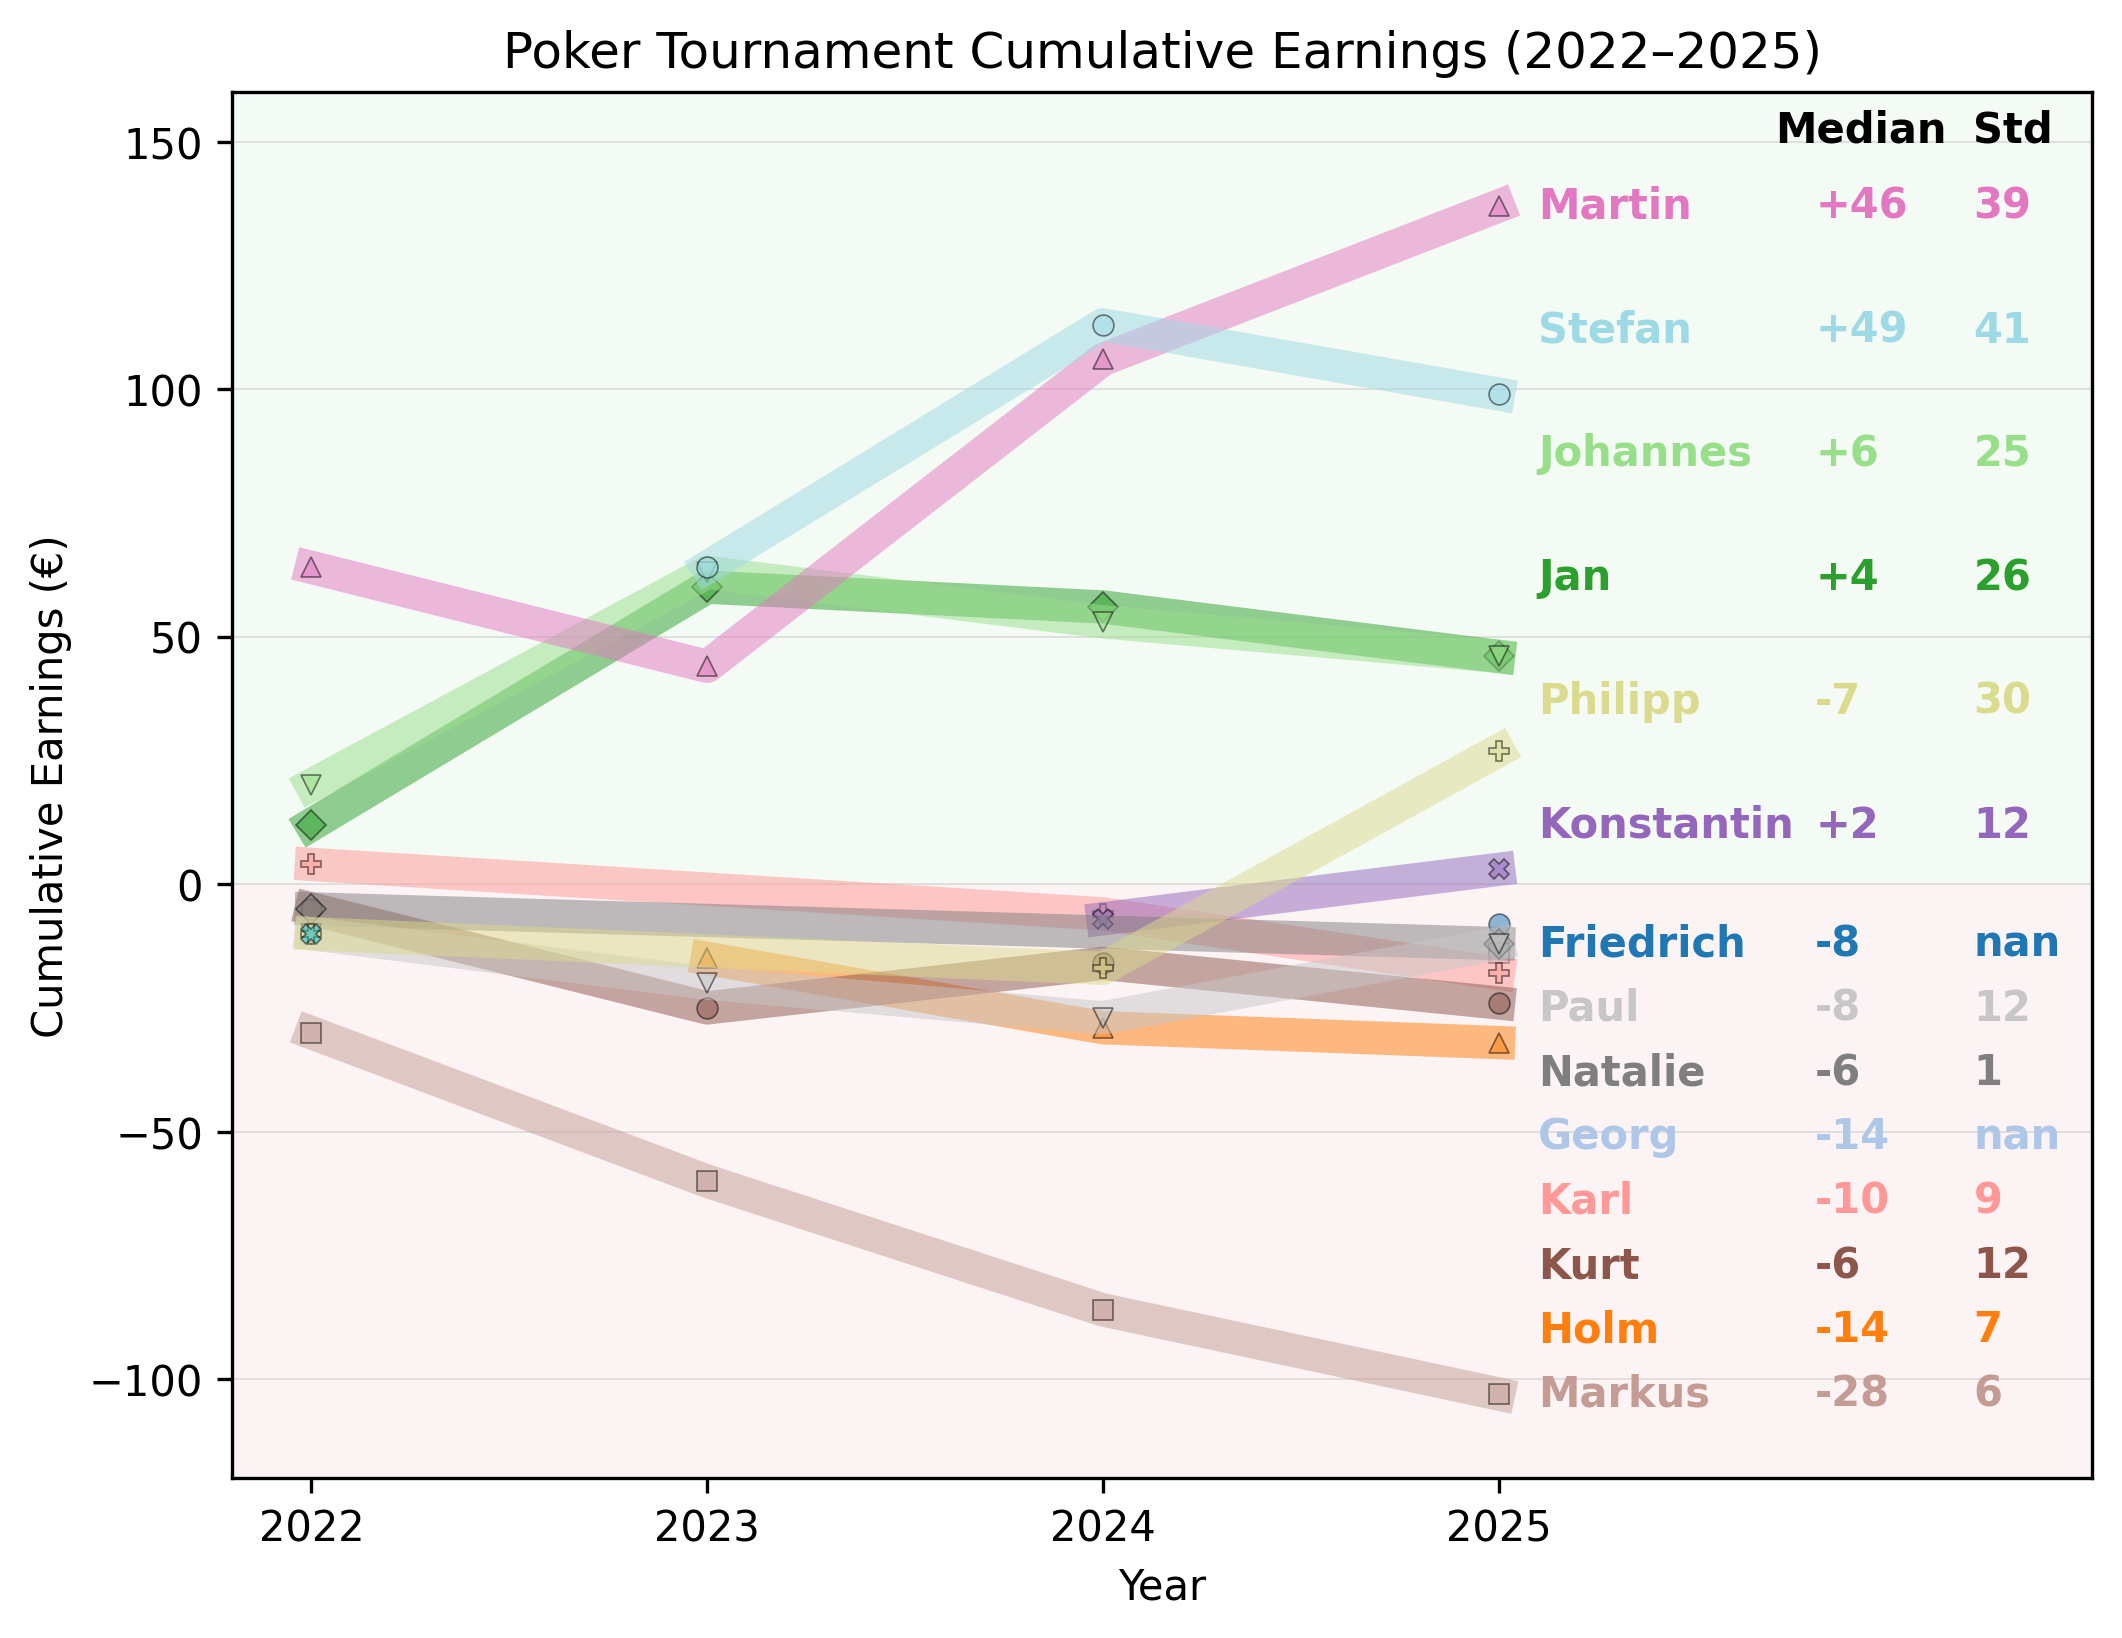

In [2]:
# 1. Load data and rules
all_data = logic.load_data(defs.DATA_PATH)
rules = logic.load_config(defs.RULES_PATH)

# 2. Compute cumulative earnings for all years
dfs = [logic.compute_net(all_data, yr, rules).assign(Year=yr)
       for yr in sorted(all_data['Year'].unique())]

df_all = pd.concat(dfs, ignore_index=True).sort_values(["Name", "Year"])
df_all["Cumulative_Earnings"] = df_all.groupby("Name")["Net_Earnings"].cumsum()

# 3. Setup Figure and Styling
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
names = sorted(df_all["Name"].unique())
colors = plt.cm.tab20(np.linspace(0, 1, len(names)))
markers = ["o", "s", "^", "D", "v", "P", "X"]
style = {n: (colors[i], markers[i % len(markers)]) for i, n in enumerate(names)}

# Set axis limits
last_year, first_year = df_all["Year"].max(), df_all["Year"].min()
ax.set_xlim(first_year - 0.2, last_year + 1.5)
ax.set_ylim(-120, 160)

# 4. Background shading using your definition colors
ax.axhspan(0, 160, facecolor=defs.COLOR_NET_POSITIVE, alpha=0.05)
ax.axhspan(-120, 0, facecolor=defs.COLOR_NET_NEGATIVE, alpha=0.05)

# 5. Plot lines
for name in names:
    d = df_all[df_all["Name"] == name].sort_values("Year")
    color, marker = style[name]
    ax.plot(d["Year"], d["Cumulative_Earnings"], color=color, marker=marker,
            linewidth=8, alpha=0.5, markersize=5, markerfacecolor=color,
            markeredgecolor="black", markeredgewidth=0.4)

# 6. Right-side Labels & Metrics
# Prepare data groups
right_labels = df_all[df_all["Year"] == last_year]
stats = df_all.groupby("Name")["Net_Earnings"].agg(['median', 'std'])

pos = right_labels[right_labels["Cumulative_Earnings"] > 0].sort_values("Cumulative_Earnings", ascending=False)
neg = right_labels[right_labels["Cumulative_Earnings"] < 0].sort_values("Cumulative_Earnings")

def plot_metrics(df_group, y_vals):
    for y, (_, row) in zip(y_vals, df_group.iterrows()):
        p = row["Name"]
        c = style[p][0]
        med = f"+{stats.loc[p, 'median']:.0f}" if stats.loc[p, 'median'] > 0 else f"{stats.loc[p, 'median']:.0f}"

        ax.text(last_year + 0.1, y, p, color=c, fontweight="bold", va="center")
        ax.text(last_year + 0.8, y, med, color=c, fontweight="bold", va="center")
        ax.text(last_year + 1.2, y, f"{stats.loc[p, 'std']:.0f}", color=c, fontweight="bold", va="center")

# Draw positive and negative sections
gap = 0.05 * (df_all["Cumulative_Earnings"].max() - df_all["Cumulative_Earnings"].min())
if len(pos) > 0:
    plot_metrics(pos, np.linspace(gap, pos["Cumulative_Earnings"].max(), len(pos))[::-1])
if len(neg) > 0:
    plot_metrics(neg, np.linspace(neg["Cumulative_Earnings"].min(), -gap, len(neg)))

# 7. Final Polish (Labels and Titles pull from global rcParams)
ax.set_xticks(sorted(all_data['Year'].unique()))
ax.set_xlabel("Year")
ax.set_ylabel("Cumulative Earnings (€)")
ax.set_title(f"Poker Tournament Cumulative Earnings ({first_year}–{last_year})")
ax.grid(True, axis="y", linewidth=0.4, alpha=0.4)

# Headers
ax.text(last_year + 0.7, 150, "Median", fontweight="bold")
ax.text(last_year + 1.2, 150, "Std", fontweight="bold")
plt.savefig("poker_cumulative_earnings.png")
plt.show()

# Placement vs year

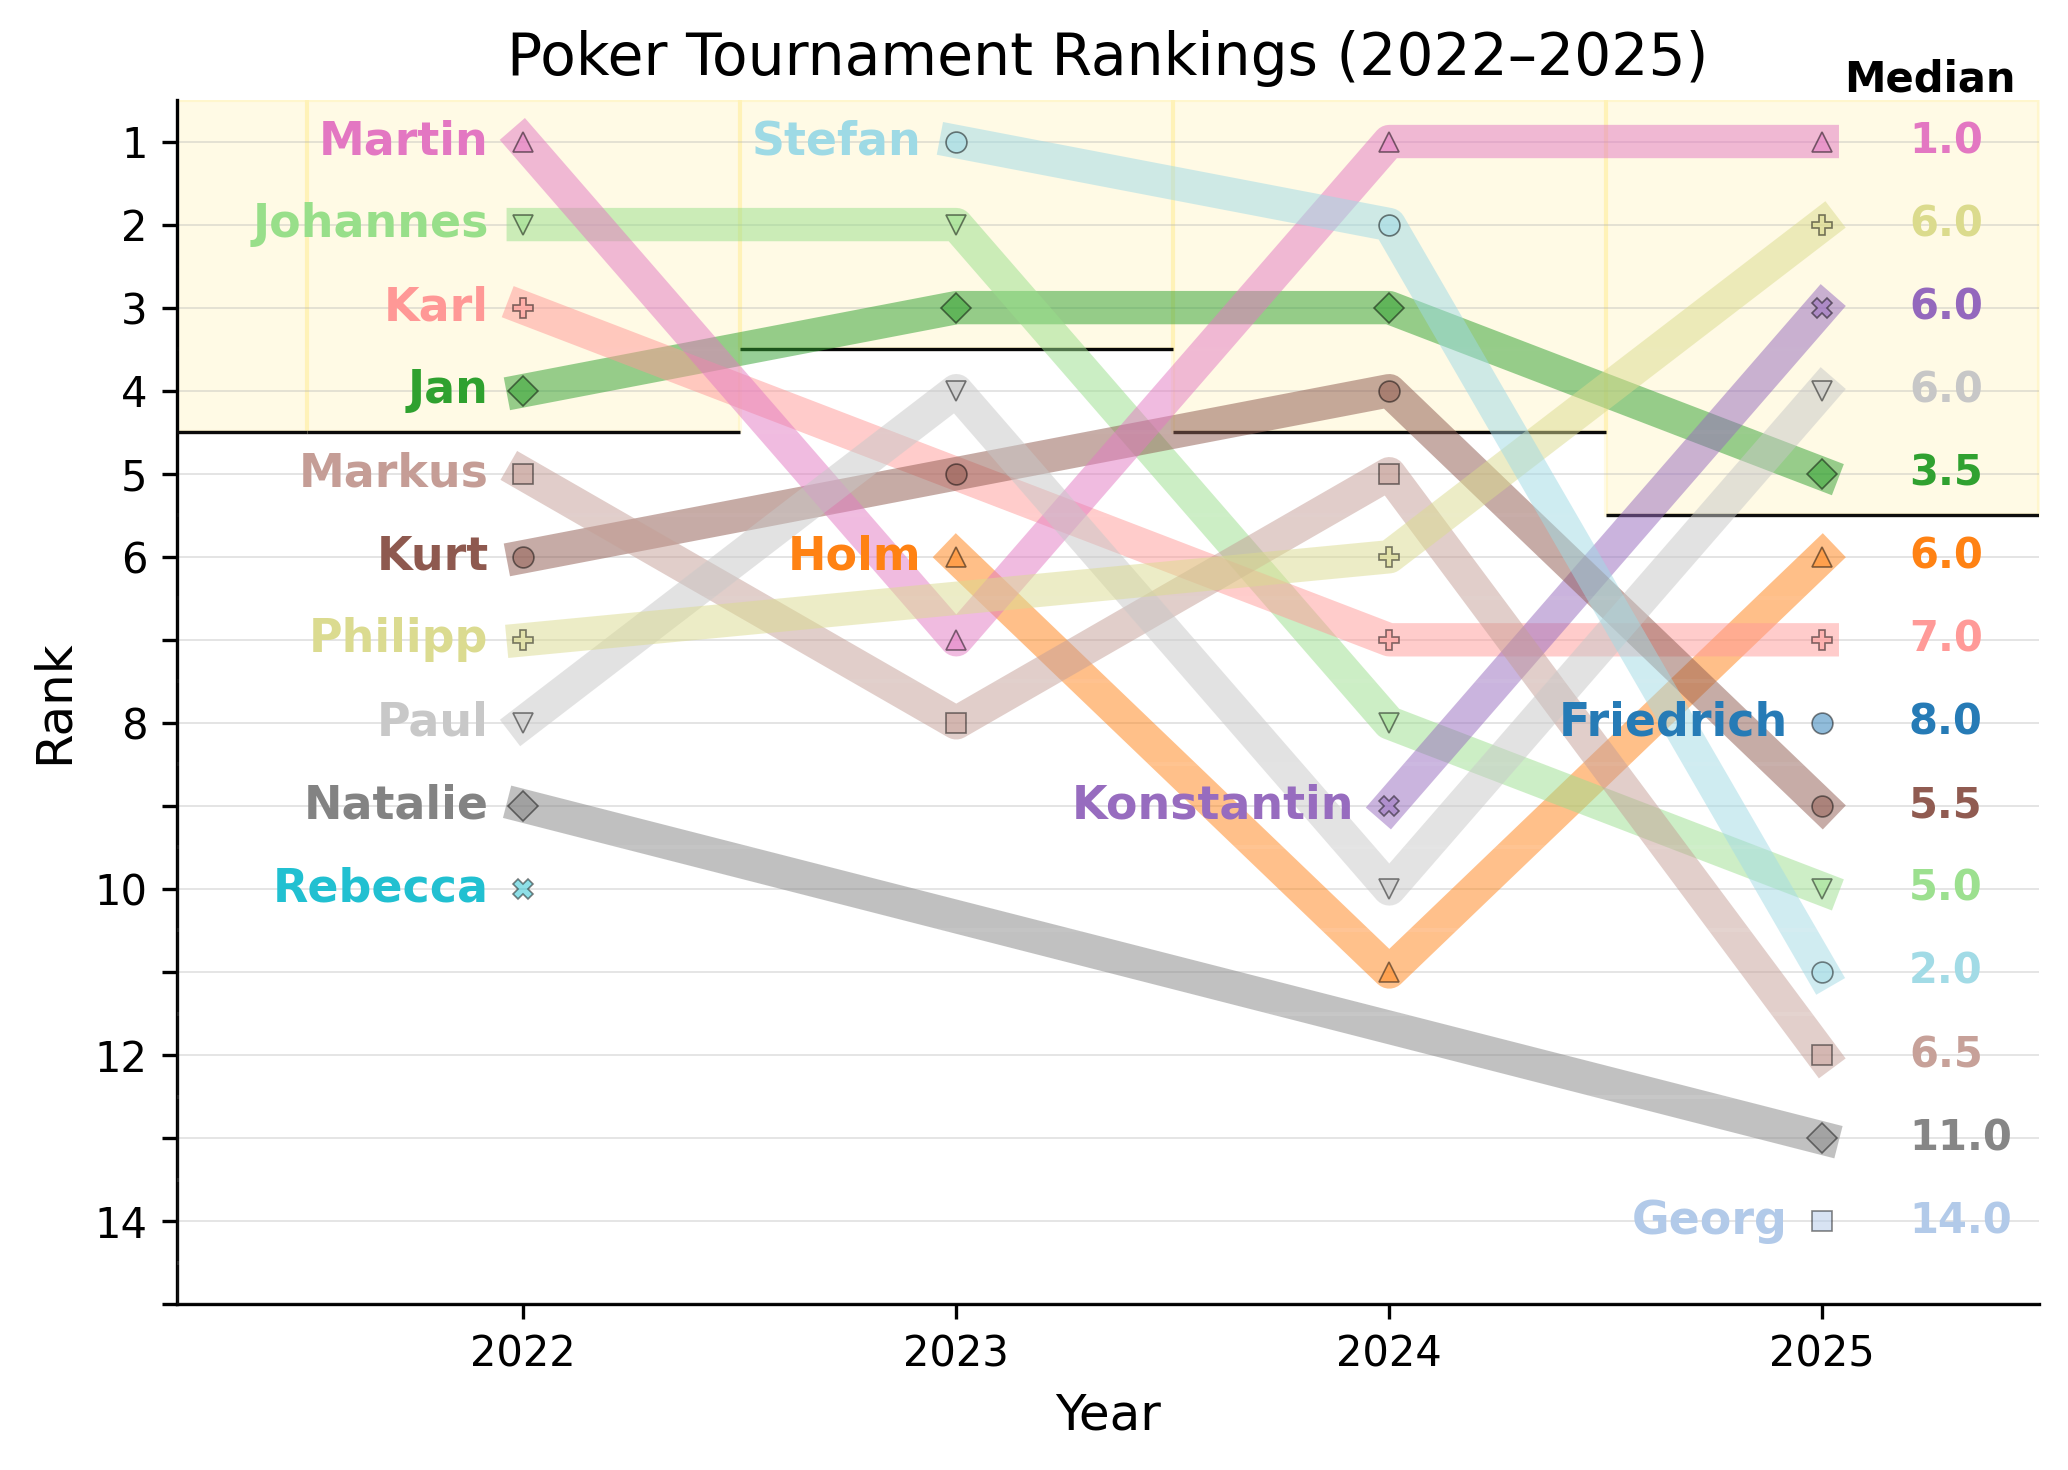

In [28]:
# 1. Load data
all_data = logic.load_data(defs.DATA_PATH)

# 2. Build Rank Dataframe
# Pulls Name and Rank from your logic/CSV structure
df = all_data[["Name", "Rank", "Year"]].copy()
years = sorted(df["Year"].unique())

# 3. Figure Setup
fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

names = sorted(df["Name"].unique())
colors = plt.cm.tab20(np.linspace(0, 1, len(names)))
markers = ["o", "s", "^", "D", "v", "P", "X"]
style = {n: (colors[i], markers[i % len(markers)]) for i, n in enumerate(names)}

# 4. Plot Lines and Start-of-Line Labels
for name in names:
    d = df[df["Name"] == name].sort_values("Year")
    color, marker = style[name]

    ax.plot(d["Year"], d["Rank"], color=color, linewidth=8, alpha=0.5,
            marker=marker, markersize=5, markerfacecolor=color,
            markeredgecolor="black", markeredgewidth=0.4)

    # Label at first appearance
    first = d.iloc[0]
    ax.text(first["Year"] - 0.08, first["Rank"], name, ha="right", va="center",
            fontweight="bold", color=color, fontsize=defs.FS_TICK + 1)

# 5. Background Styling (Gradient & Highlights)
# White gradient for lower ranks
ranks = np.arange(1, 16)
alphas = (ranks - 1) * (0.1 / 13) # Subtle fade to 0.1 opacity
for r, a in zip(ranks, alphas):
    ax.fill_between([years[0] - 1, years[-1] + 1], r - 0.5, r + 0.5,
                    color="#FFFFFF", alpha=a * 0.6, zorder=5)

# Gold Highlights for "Top Tier" each year
# (Year: Rank_Limit)
top_tier_map = {2021: 4.5, 2022: 4.5, 2024: 4.5, 2023: 3.5, 2025: 5.5}
top_color = "#FFD700"

for yr, limit in top_tier_map.items():
    ax.fill_between([yr - 0.5, yr + 0.5], 0.5, limit, color=top_color, alpha=0.1, zorder=0)
    ax.hlines(y=limit, xmin=yr-0.5, xmax=yr+0.5, color='black', linewidth=0.8, zorder=1)

# 6. Axes & Ticks
ax.set_ylim(df["Rank"].max() + 0.5, 0.5) # Inverted Y-axis for Ranks
ax.set_xlim(2021.2, years[-1] + 0.5)
ax.set_xticks(years)
ax.set_yticks(range(1, 16))
ax.set_yticklabels([str(r) if r <= 6 or r % 2 == 0 else "" for r in range(1, 16)])

ax.set_ylabel("Rank")
ax.set_xlabel("Year")
ax.set_title(f"Poker Tournament Rankings ({years[0]}–{years[-1]})")
ax.grid(True, axis="y", linewidth=0.4, alpha=0.4)

# 7. Median Column (Right side)
expected_rank = df.groupby("Name")["Rank"].median()
x_pos_median = years[-1] + 0.2

# Header
ax.text(x_pos_median - 0.15, 0.5, "Median", ha="left", va="bottom", fontweight="bold")

# Labels based on last year's order
df_last = df[df["Year"] == years[-1]].sort_values("Rank")
for row in df_last.itertuples():
    ax.text(x_pos_median, row.Rank, f"{expected_rank[row.Name]:.1f}",
            ha="left", va="center", fontweight="bold", color=style[row.Name][0])

fig.tight_layout()
plt.savefig("poker_rankings_historical.png")
plt.show()

# Knockouts vs. Person

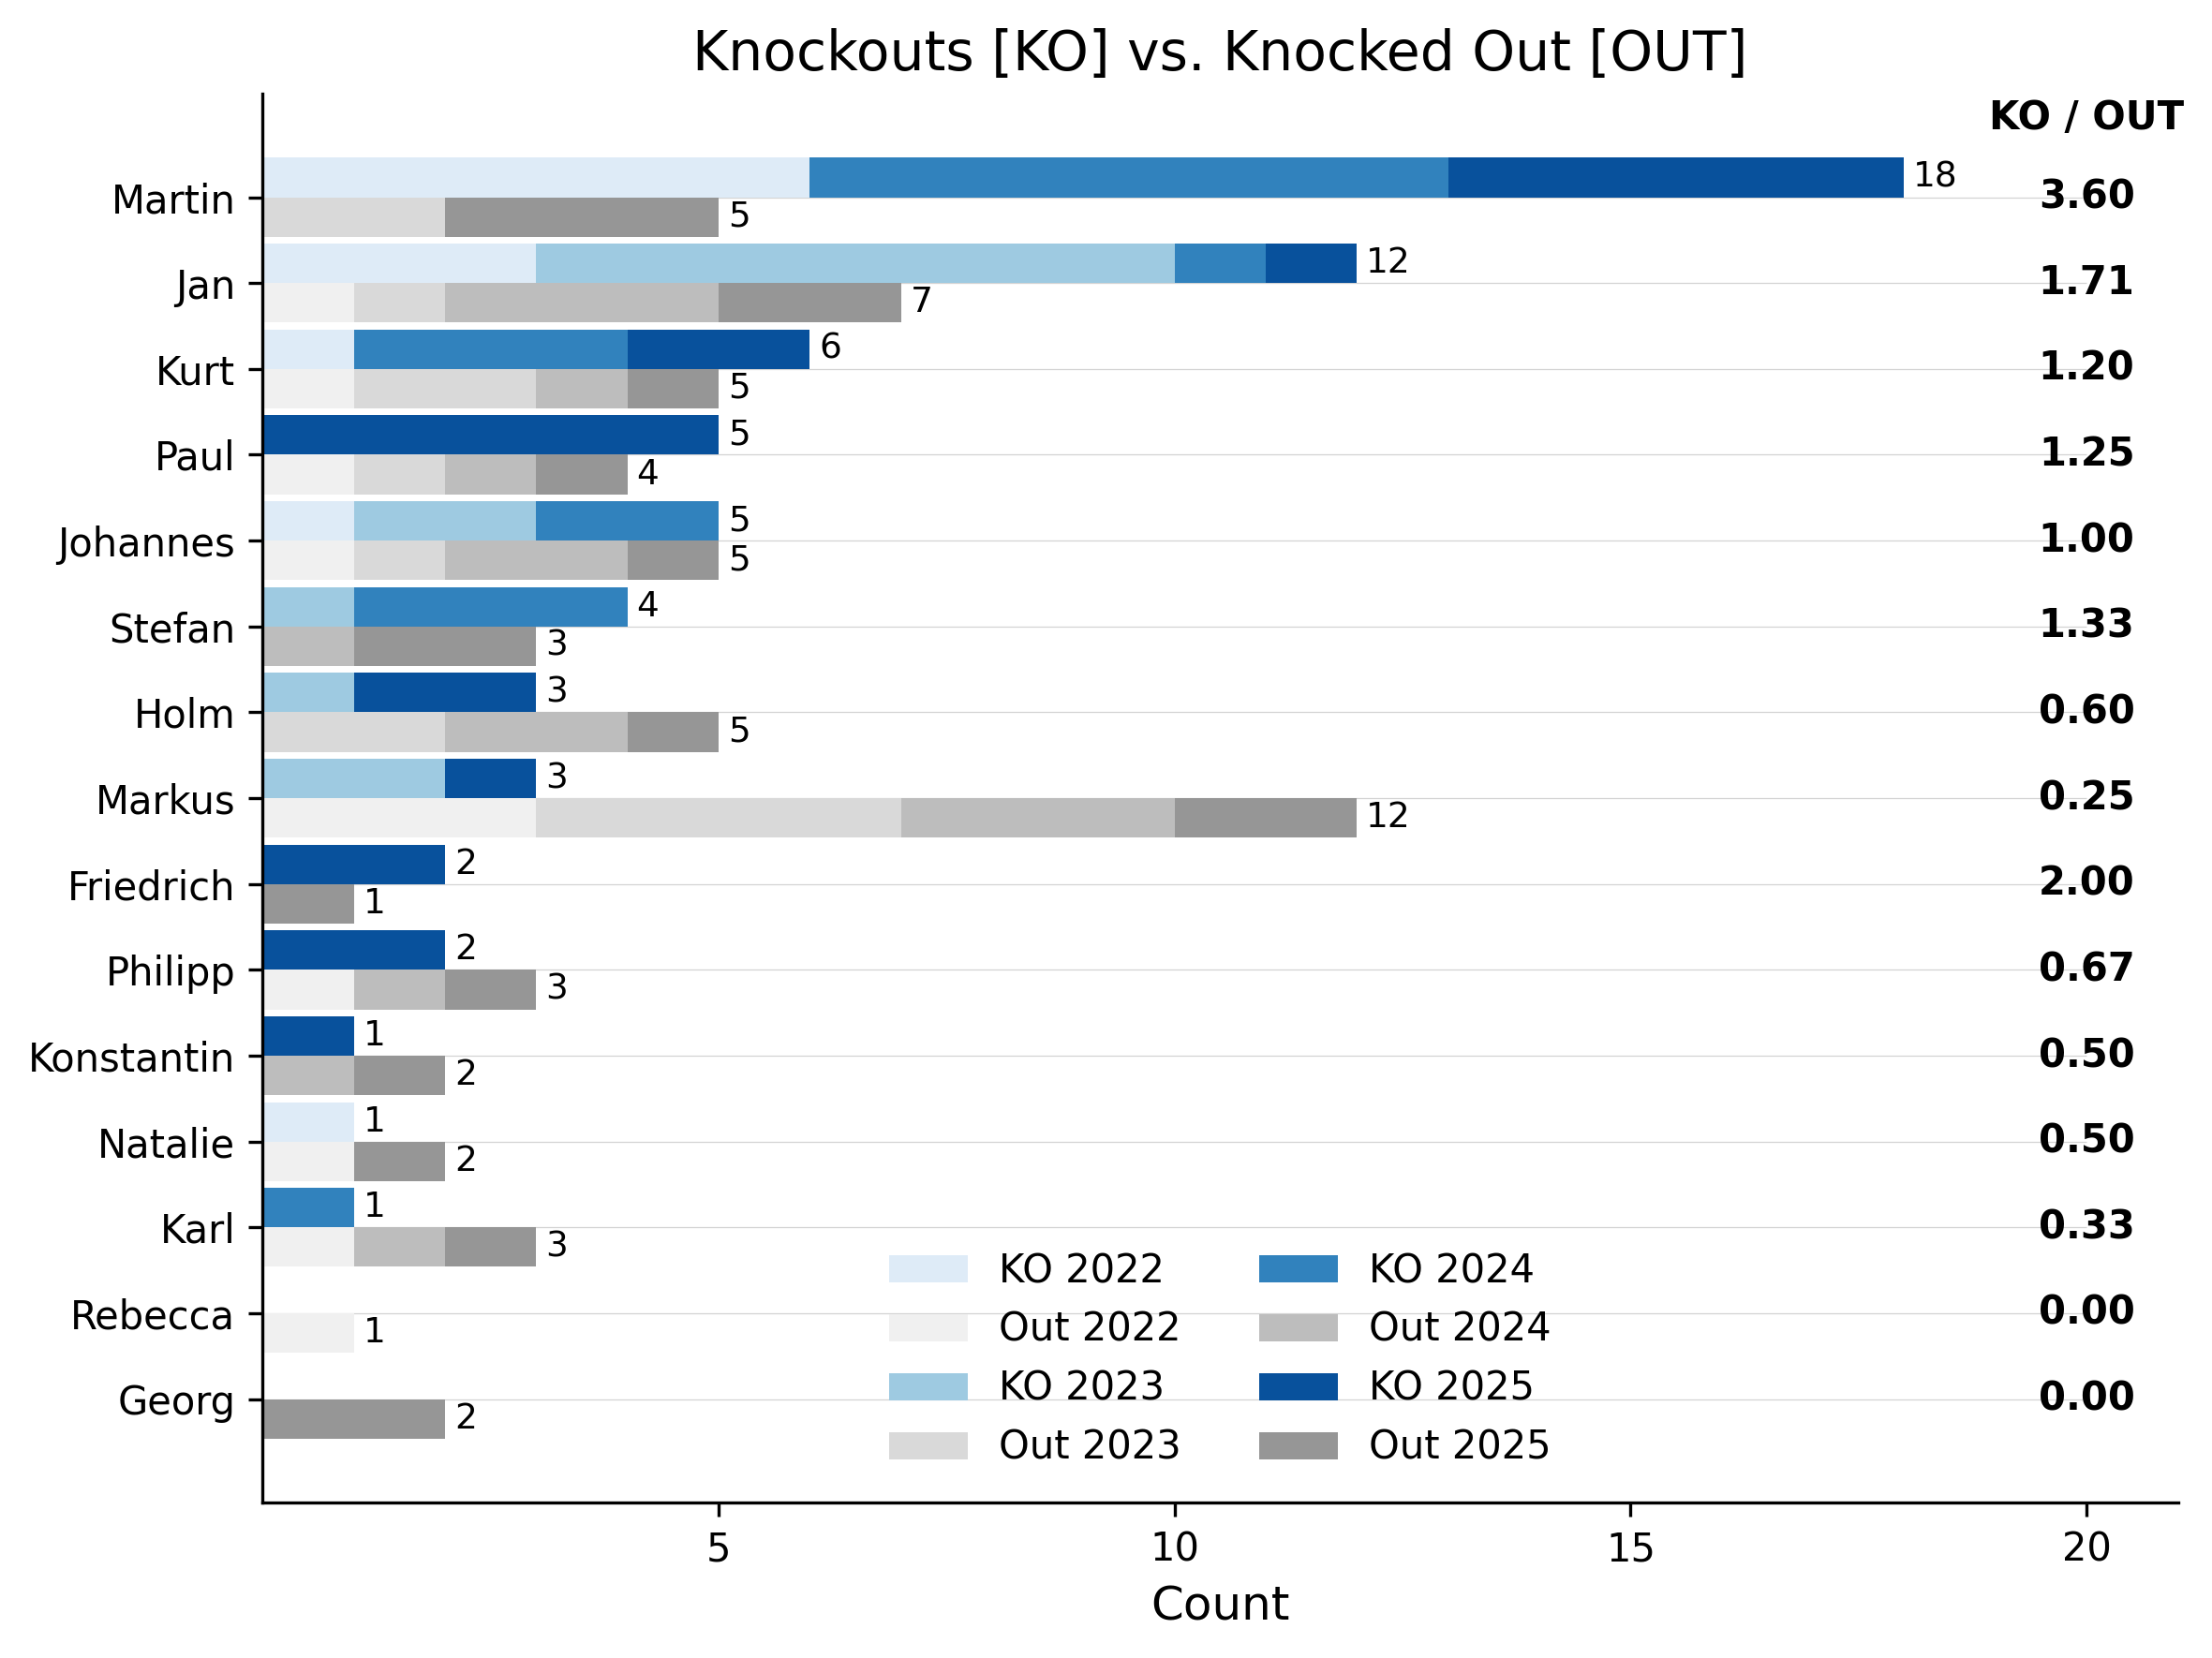

In [31]:
# 1. Load Data
all_data = logic.load_data(defs.DATA_PATH)
years = sorted(all_data['Year'].unique())
all_names = sorted(all_data['Name'].unique())

# 2. Build full DataFrame for KO/OUT tracking
# We pivot the data to get one row per player and columns for each year's metrics
df_list = []
for year in years:
    # Get participant data for this year
    d = all_data[all_data['Year'] == year].copy()

    # Calculate OUT: Rebuys + 1 (if they didn't win)
    d['OUT'] = d['Rebuy'] + d['Rank'].apply(lambda r: 1 if r != 1 else 0)

    # Select relevant columns and rename for the merge
    d_year = d[['Name', 'Knockouts', 'OUT', 'Addon']].copy()
    d_year.columns = ['Name', f'KO_{year}', f'OUT_{year}', f'Addon_{year}']
    df_list.append(d_year)

# Merge all years into one main dataframe
df = pd.DataFrame({'Name': all_names})
for d_yr in df_list:
    df = pd.merge(df, d_yr, on='Name', how='left').fillna(0)

# 3. Compute Totals and Sort
df["Total_KO"] = df[[f"KO_{y}" for y in years]].sum(axis=1)
df["Total_OUT"] = df[[f"OUT_{y}" for y in years]].sum(axis=1)

df = df.sort_values(["Total_KO", "Total_OUT"], ascending=[False, True]).iloc[::-1]

# 4. Positions & Colors
y = np.arange(len(df))
bar_h = 0.46
y_ko, y_out = y + bar_h/2, y - bar_h/2

ko_colors = {"2022":"#deebf7", "2023":"#9ecae1", "2024":"#3182bd", "2025":"#08519c"}
out_colors = {"2022":"#f0f0f0", "2023":"#d9d9d9", "2024":"#bdbdbd", "2025":"#969696"}

# 5. Plotting
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# Stacked Bars for KO and OUT
for yr in years:
    # KO bars
    left_ko = df[[f"KO_{y}" for y in years if y < yr]].sum(axis=1)
    ax.barh(y_ko, df[f"KO_{yr}"], left=left_ko, height=bar_h,
            color=ko_colors.get(str(yr), "#000000"), label=f"KO {yr}")

    # OUT bars
    left_out = df[[f"OUT_{y}" for y in years if y < yr]].sum(axis=1)
    ax.barh(y_out, df[f"OUT_{yr}"], left=left_out, height=bar_h,
            color=out_colors.get(str(yr), "#000000"), label=f"Out {yr}")

# 6. Labels and Ratio Column
max_bar = max(df["Total_KO"].max(), df["Total_OUT"].max())
ratio_x = max_bar + 2

# Ratio Header
ax.text(ratio_x, y_ko.max() + bar_h, "KO / OUT", ha="center", va="bottom", fontweight="bold")

for i, (name, ko, out) in enumerate(zip(df["Name"], df["Total_KO"], df["Total_OUT"])):
    # Value labels on bars
    if ko > 0: ax.text(ko + 0.1, y_ko[i], int(ko), va="center", fontsize=9)
    if out > 0: ax.text(out + 0.1, y_out[i], int(out), va="center", fontsize=9)

    # Ratio calculation
    ratio = ko / out if out > 0 else 0
    ax.text(ratio_x, y[i], f"{ratio:.2f}", ha="center", va="center", fontweight="bold")

    # Background guide lines
    ax.hlines(y[i], 0, ratio_x, color='lightgrey', linewidth=0.3, zorder=0)

# 7. Final Polish
ax.set_yticks(y)
ax.set_yticklabels(df["Name"])
ax.set_xlabel("Count")
ax.set_title("Knockouts [KO] vs. Knocked Out [OUT]")
ax.set_xlim(0, ratio_x + 1)
ax.set_xticks([5, 10, 15, 20])

# Clean Legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), frameon=False, loc="lower center", ncol=2)

plt.tight_layout()
plt.savefig("poker_ko_efficiency.png")
plt.show()